# Data Preprocessing

In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

from sklearn.neighbors import KNeighborsClassifier 
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier 
from xgboost import XGBClassifier 
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression


from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

e:\Desktop\Projects\greenvision\venv\Lib\site-packages\xgboost\compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


**Import the CSV Data as Pandas DataFrame** 

In [3]:
df = pd.read_csv('data/covtype.csv')
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


### Data Cleaning

Checking features with nan values

In [4]:
features_with_na = [feature for feature in df.columns if df[feature].isnull().sum()>=1]
for feature in features_with_na:
    print(feature, np.round(df[feature].isnull().mean(),4), '% missing values')

**Handling DUplicates**

In [5]:
df.duplicated().sum()

np.int64(0)

## Feature Engineering

In [6]:
# Type of features
#NUMERIC FEATURES
numeric_features = [feature for feature in df.columns if df[feature].dtype !='O']
print('Number of numerical features: ', len(numeric_features))

Number of numerical features:  55


In [7]:
#CATEGORICAL FEATURES
categorical_features = [feature for feature in df.columns if df[feature].dtype =='O']
print('Number of categorical features: ', len(categorical_features))

Number of categorical features:  0


In [8]:
#DISCRETE FEATURES
discrete_features = [feature for feature in numeric_features if len(df[feature].unique())<=25]
print('Number of discrete features: ', len(discrete_features))

Number of discrete features:  45


In [9]:
#CONTINUOUS FEATURES
continuous_features = [feature for feature in numeric_features if feature not in discrete_features]
print('Number of continuous features: ', len(continuous_features))

Number of continuous features:  10


### Check Outlier and capping it

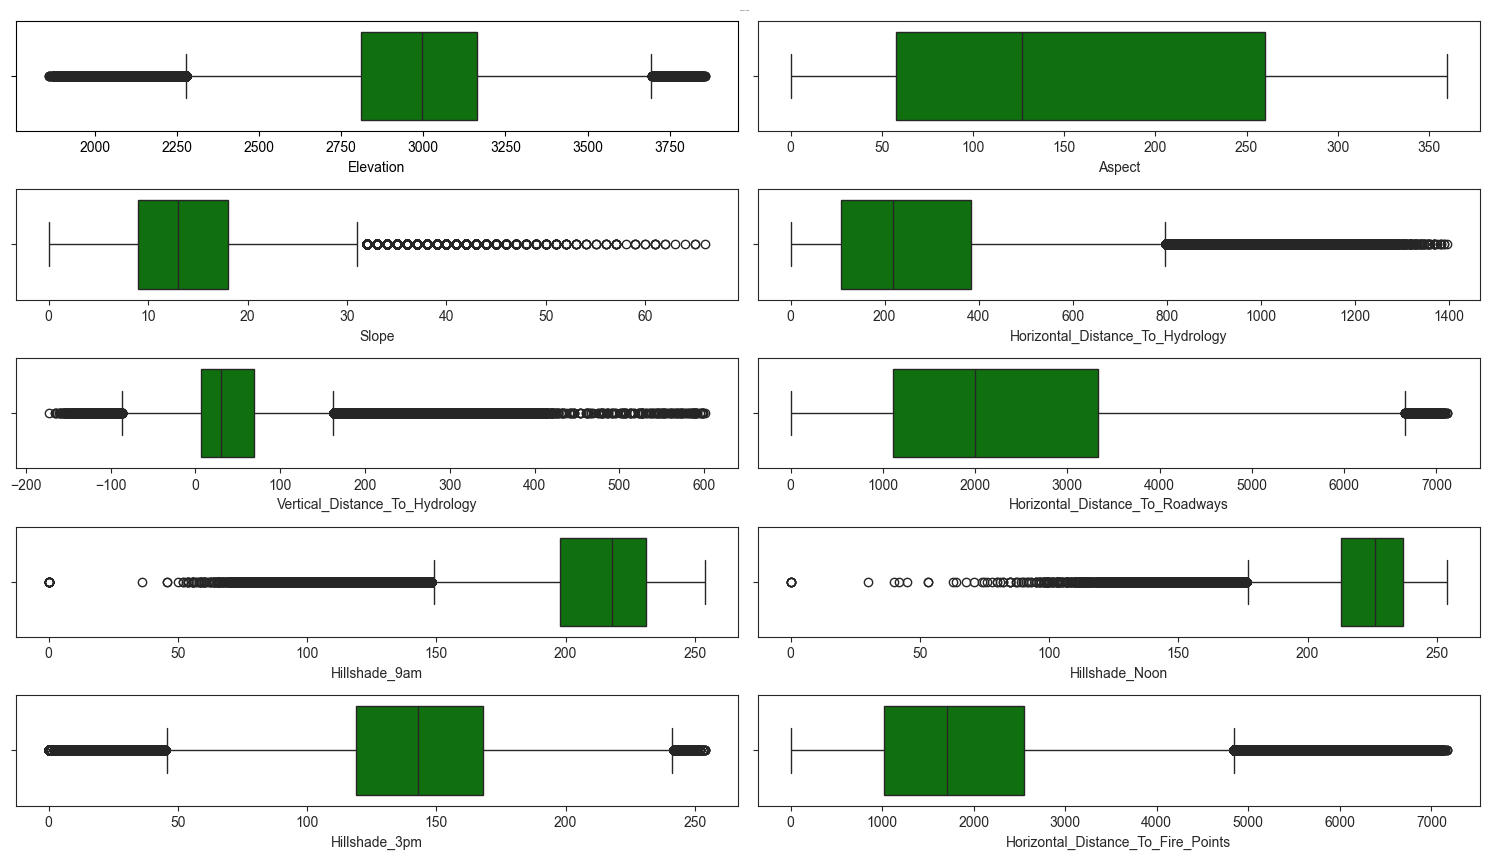

In [10]:
plt.figure(figsize=(15,10))
plt.suptitle('Check Outliers', fontsize=0)
for i in range(0, len(continuous_features)):
    plt.subplot(6,2,i+1)
    sns.set_style('ticks')
    sns.boxplot(df[continuous_features[i]], color='green', orient='h')
    plt.tight_layout()

Insight
* Except 'Aspect' rest all other 9 continuous features has outliers

In [11]:
df_copy = df.copy()
def detect_and_capping_outliers(col):
    percentile25 = df_copy[col].quantile(0.25)
    percentile75 = df_copy[col].quantile(0.75)
    iqr = percentile75 - percentile25
    upper_limit = percentile75 + (1.5 * iqr)
    lower_limit = percentile25 - (1.5 * iqr)
    df_copy.loc[(df_copy[col]>upper_limit), col] = upper_limit
    df_copy.loc[(df_copy[col]<lower_limit), col] = lower_limit      
    return df_copy


In [12]:
for col in continuous_features:
    detect_and_capping_outliers(col)

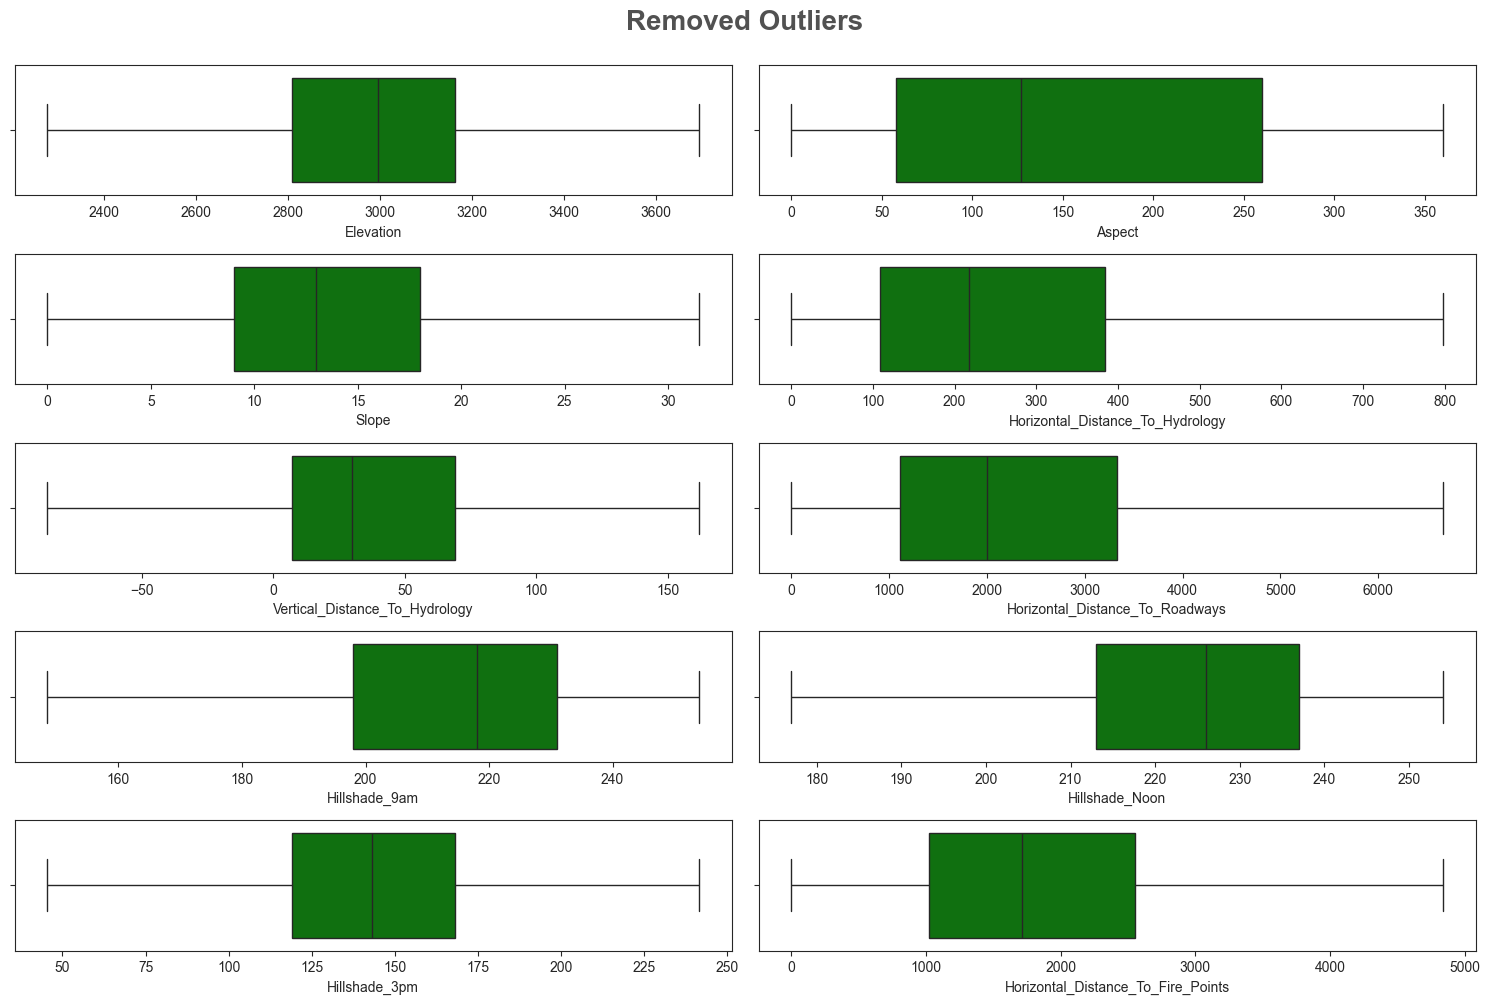

In [13]:
plt.figure(figsize=(15, 10))
plt.suptitle('Removed Outliers', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
for i in range(0, len(continuous_features)):
    plt.subplot(5,2,i+1)
    sns.set_style('ticks')
    sns.boxplot(df_copy[continuous_features[i]], color='green', orient='h')
    plt.tight_layout()

Create one column as Wilderness_Area_Type and represent it as categorical data

In [14]:
df['Wilderness_Area1']

0         1
1         1
2         1
3         1
4         1
         ..
581007    0
581008    0
581009    0
581010    0
581011    0
Name: Wilderness_Area1, Length: 581012, dtype: int64

In [15]:
df['Wilderness_Area_Type'] = (df.iloc[:, 10:15]==1).idxmax(1)
wilderness_areas = sorted(df['Wilderness_Area_Type'].value_counts().index.tolist())

In [16]:
wilderness_areas

['Wilderness_Area1',
 'Wilderness_Area2',
 'Wilderness_Area3',
 'Wilderness_Area4']

In [17]:
# df['Wilderness_Area1']

In [18]:
def split_numbers_chars(row):
    '''This function fetches the numerical characters at the end of a string
    and returns alphabetical character and numerical charcters respectively'''
    head = row.rstrip('0123456789')
    tail = row[len(head):]
    return head, tail

def reverse_one_hot_encode(dataframe, start_loc, end_loc, numeric_column_name):
    ''' this function takes the start and end location of the one-hot-encoded column set and numeric column name to be created as arguments
    1) transforms one-hot-encoded columns into one column consisting of column names with string data type
    2) splits string column into the alphabetical and numerical characters
    3) fetches numerical character and creates numeric column in the given dataframe
    '''
    dataframe['String_Column'] = (dataframe.iloc[:, start_loc:end_loc] == 1).idxmax(1)
    dataframe['Tuple_Column'] = dataframe['String_Column'].apply(split_numbers_chars)
    dataframe[numeric_column_name] = dataframe['Tuple_Column'].apply(lambda x: x[1]).astype('int64')
    dataframe.drop(columns=['String_Column','Tuple_Column'], inplace=True)

In [19]:
df_copy = df.copy()
reverse_one_hot_encode(df_copy, 14, 56, 'Soil_Type')

# reverse_one_hot_encode(df_copy, 10, 14, 'Wilderness_Area')

In [20]:
df_copy

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type,Wilderness_Area_Type,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,5,Wilderness_Area1,29
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,5,Wilderness_Area1,29
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,2,Wilderness_Area1,12
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,2,Wilderness_Area1,30
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,5,Wilderness_Area1,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,2396,153,20,85,17,108,240,237,118,837,...,0,0,0,0,0,0,0,3,Wilderness_Area3,2
581008,2391,152,19,67,12,95,240,237,119,845,...,0,0,0,0,0,0,0,3,Wilderness_Area3,2
581009,2386,159,17,60,7,90,236,241,130,854,...,0,0,0,0,0,0,0,3,Wilderness_Area3,2
581010,2384,170,15,60,5,90,230,245,143,864,...,0,0,0,0,0,0,0,3,Wilderness_Area3,2


In [21]:
feature_names = continuous_features + wilderness_areas + ["Soil_Type"] + ["Cover_Type"]
all_features_df = df_copy[feature_names]
all_features_df

# wilderness_areas

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Soil_Type,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,1,0,0,0,29,5
1,2590,56,2,212,-6,390,220,235,151,6225,1,0,0,0,29,5
2,2804,139,9,268,65,3180,234,238,135,6121,1,0,0,0,12,2
3,2785,155,18,242,118,3090,238,238,122,6211,1,0,0,0,30,2
4,2595,45,2,153,-1,391,220,234,150,6172,1,0,0,0,29,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,2396,153,20,85,17,108,240,237,118,837,0,0,1,0,2,3
581008,2391,152,19,67,12,95,240,237,119,845,0,0,1,0,2,3
581009,2386,159,17,60,7,90,236,241,130,854,0,0,1,0,2,3
581010,2384,170,15,60,5,90,230,245,143,864,0,0,1,0,2,3


### Visualize the Class Distribution

In [22]:
all_features_df['Cover_Type'] = all_features_df['Cover_Type']-1

In [23]:
all_features_df['Cover_Type'].value_counts()

Cover_Type
1    283301
0    211840
2     35754
6     20510
5     17367
4      9493
3      2747
Name: count, dtype: int64

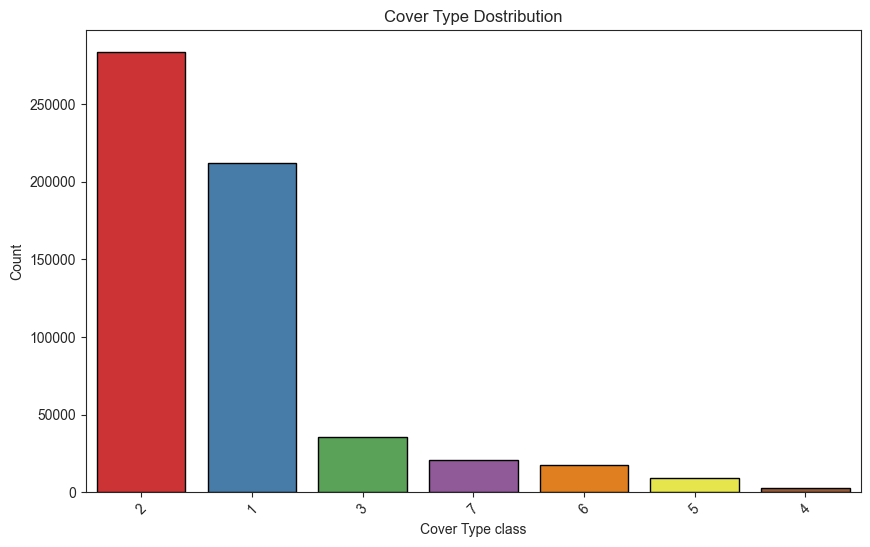

In [24]:
plt.subplots(figsize=(10, 6))
sns.countplot(x='Cover_Type', data = df, ec = 'black', palette='Set1', order = df['Cover_Type'].value_counts().index)
plt.title("Cover Type Dostribution")
plt.ylabel("Count")
plt.xlabel("Cover Type class" )
plt.xticks(rotation=45)
plt.show()

Inference
* As most of the data is of class 0 and class 1 type 
* So its a clear case of imbalance

In [25]:
def split_and_scale_data(df):
    df=df.copy()
    X = df.drop(columns='Cover_Type', axis=1)
    y = df['Cover_Type']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

    return X_train, X_test, y_train, y_test

In [26]:
def evaluate_model(model, balanced_class, X_test, y_test):
    model_accuracy = model.score(X_test, y_test)
    print(f"Accuracy of {balanced_class} model: {model_accuracy*100:.2f}%")

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    cl_report = classification_report(y_test, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix for {balanced_class} model')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')    
    plt.show()

    print(f'Classification Report for {balanced_class} model:\n', cl_report)
    return model_accuracy

In [27]:
imbalanced_data = all_features_df.copy()
X_train, X_test, y_train, y_test = split_and_scale_data(imbalanced_data)

model_1 = RandomForestClassifier()
model_1.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Accuracy of Imbalanced model: 95.93%


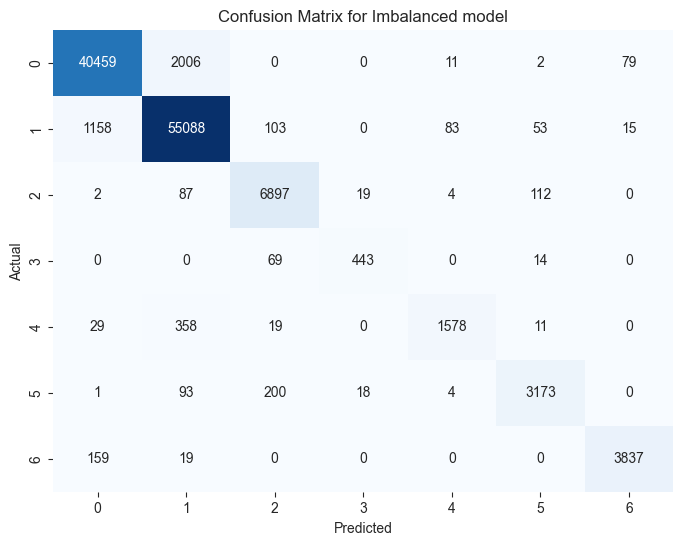

Classification Report for Imbalanced model:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96     42557
           1       0.96      0.98      0.97     56500
           2       0.95      0.97      0.96      7121
           3       0.92      0.84      0.88       526
           4       0.94      0.79      0.86      1995
           5       0.94      0.91      0.93      3489
           6       0.98      0.96      0.97      4015

    accuracy                           0.96    116203
   macro avg       0.95      0.91      0.93    116203
weighted avg       0.96      0.96      0.96    116203



0.959312582291335

In [28]:
evaluate_model(model_1, 'Imbalanced', X_test, y_test)

Accuracy of Imbalanced model: 71.52%


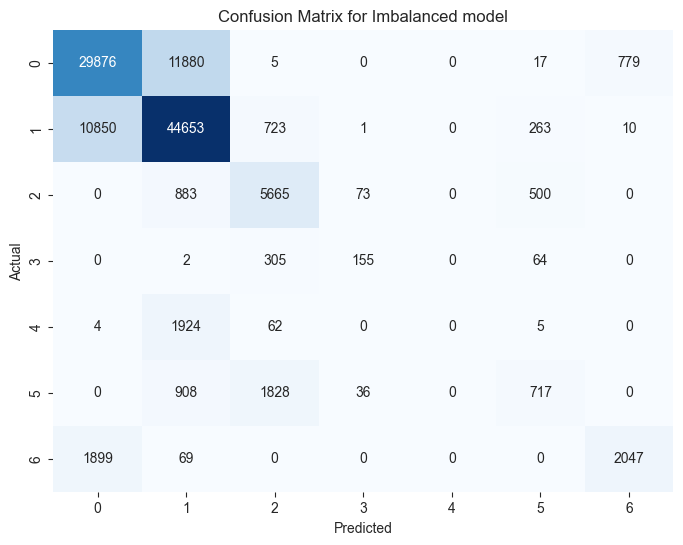

Classification Report for Imbalanced model:
               precision    recall  f1-score   support

           0       0.70      0.70      0.70     42557
           1       0.74      0.79      0.76     56500
           2       0.66      0.80      0.72      7121
           3       0.58      0.29      0.39       526
           4       0.00      0.00      0.00      1995
           5       0.46      0.21      0.28      3489
           6       0.72      0.51      0.60      4015

    accuracy                           0.72    116203
   macro avg       0.55      0.47      0.49    116203
weighted avg       0.70      0.72      0.70    116203



0.7152397098181631

In [29]:
model_2 = LogisticRegression()
model_2.fit(X_train, y_train)
evaluate_model(model_2, 'Imbalanced', X_test, y_test)

In [30]:
y_pred_probabilities = model_2.predict_proba(X_test)

In [31]:
y_pred_probabilities

array([[5.30868134e-01, 4.38659406e-01, 3.54954585e-10, ...,
        5.39831047e-04, 4.86079380e-10, 2.99326282e-02],
       [4.23534267e-02, 8.64909240e-01, 3.08747610e-03, ...,
        6.63990587e-02, 2.32144596e-02, 9.95320366e-06],
       [1.29474858e-02, 4.94031733e-01, 1.53931705e-01, ...,
        3.39246154e-02, 3.05040793e-01, 1.69561046e-08],
       ...,
       [1.27506861e-01, 8.59080593e-01, 3.43802967e-07, ...,
        1.33266880e-02, 1.37249182e-06, 4.88753630e-05],
       [1.24560067e-01, 8.72099145e-01, 5.12396110e-07, ...,
        3.12388623e-03, 7.98455763e-07, 7.59614958e-05],
       [2.30085349e-01, 7.35952397e-02, 1.01997221e-08, ...,
        1.23195571e-04, 2.44754392e-07, 6.96195960e-01]],
      shape=(116203, 7))

Inference 
* From the above confusion matrix we can observe that most of the true negatives are from class 1 and class 2 only
* We have huge disconnection between over represented classes and under represented classes

## 1.Random Under-Sampling

It consists of removing samples from the majority class(under-sampling)

In [32]:
under_sampled_data = imbalanced_data.copy()
under_sampled_data['Cover_Type'].value_counts()

Cover_Type
1    283301
0    211840
2     35754
6     20510
5     17367
4      9493
3      2747
Name: count, dtype: int64

In [33]:
minimum_class_size = np.min(under_sampled_data['Cover_Type'].value_counts().values)
print(minimum_class_size)

2747


In [34]:
class_subsets = [under_sampled_data.query("Cover_Type == " + str(i)) for i in range(7)]
class_subsets[0]

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Soil_Type,Cover_Type
40,2699,347,3,0,0,2096,213,234,159,6853,1,0,0,0,20,0
51,2739,323,25,85,43,3118,149,205,192,6219,1,0,0,0,29,0
52,2696,72,2,30,0,3271,222,234,149,6071,1,0,0,0,30,0
55,2722,315,24,30,19,3216,148,212,200,6132,1,0,0,0,16,0
67,2919,13,13,90,6,5321,207,214,142,4060,1,0,0,0,29,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
565432,2826,72,14,67,13,2984,235,213,106,2082,0,0,1,0,24,0
565433,2820,69,14,42,7,2954,234,211,106,2065,0,0,1,0,24,0
565434,2812,67,16,30,0,2925,234,206,99,2047,0,0,1,0,24,0
565527,2832,45,17,85,19,2989,222,200,106,2058,0,0,1,0,24,0


## Undersample the majority class
* we will go through the each class subsets and sample 2747 records

In [35]:
class_subsets = [under_sampled_data.query(f'Cover_Type=={i}') for i in range(7)]

for i in range(7):
    class_subsets[i] = class_subsets[i].sample(minimum_class_size, random_state=42)
under_sampled_data = pd.concat(class_subsets, axis=0).sample(frac=1).reset_index(drop=True)

In [36]:
under_sampled_data['Cover_Type'].value_counts()

Cover_Type
0    2747
1    2747
6    2747
4    2747
3    2747
2    2747
5    2747
Name: count, dtype: int64

In [37]:
X_train, X_test, y_train, y_test = split_and_scale_data(under_sampled_data)

model_1 = RandomForestClassifier()
model_1.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Accuracy of Undersampling model: 86.97%


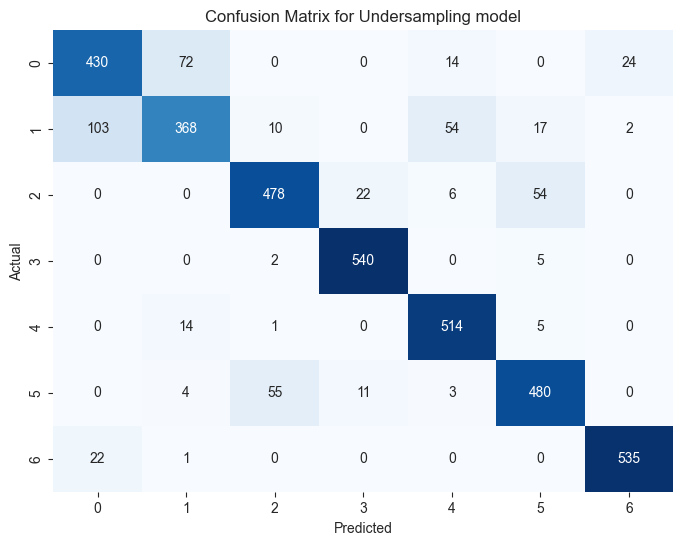

Classification Report for Undersampling model:
               precision    recall  f1-score   support

           0       0.77      0.80      0.79       540
           1       0.80      0.66      0.73       554
           2       0.88      0.85      0.86       560
           3       0.94      0.99      0.96       547
           4       0.87      0.96      0.91       534
           5       0.86      0.87      0.86       553
           6       0.95      0.96      0.96       558

    accuracy                           0.87      3846
   macro avg       0.87      0.87      0.87      3846
weighted avg       0.87      0.87      0.87      3846



0.8697347893915757

In [38]:
evaluate_model(model_1, 'Undersampling', X_test, y_test)

## 2. Random Oversampling
It consists of adding more examples from the minority class(over-sampling)

In [39]:
over_sampled_data = all_features_df.copy()
maximum_class_size = np.max(over_sampled_data['Cover_Type'].value_counts().values)
print(maximum_class_size)

283301


### OverSampling the minority class
* We will go through the each class subsets and sample 2747 records

In [40]:
class_subsets = [over_sampled_data.query("Cover_Type=="+str(i)) for i in range(7)]

for i in range(7):
    class_subsets[i] = class_subsets[i].sample(maximum_class_size, replace=True, random_state=42)
over_sampled_data = pd.concat(class_subsets, axis=0).sample(frac=1).reset_index(drop=True)

In [41]:
over_sampled_data['Cover_Type'].value_counts()

Cover_Type
2    283301
6    283301
5    283301
0    283301
3    283301
1    283301
4    283301
Name: count, dtype: int64

In [42]:
X_train, X_test, y_train, y_test = split_and_scale_data(over_sampled_data)

rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Accuracy of Oversampling model: 99.56%


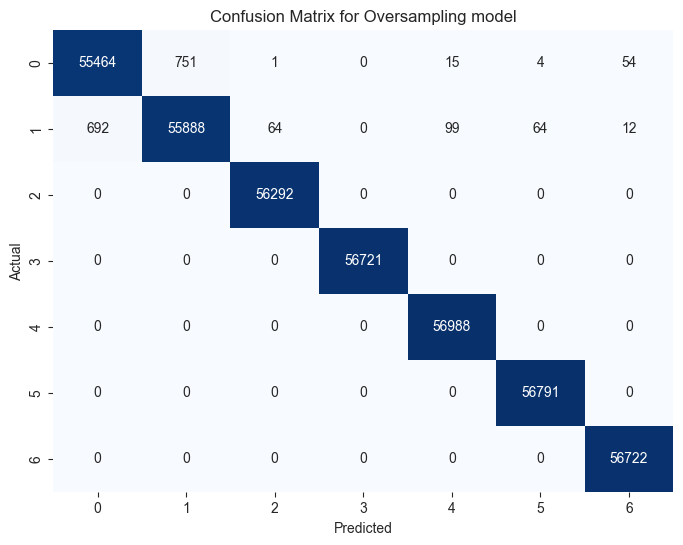

Classification Report for Oversampling model:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     56289
           1       0.99      0.98      0.99     56819
           2       1.00      1.00      1.00     56292
           3       1.00      1.00      1.00     56721
           4       1.00      1.00      1.00     56988
           5       1.00      1.00      1.00     56791
           6       1.00      1.00      1.00     56722

    accuracy                           1.00    396622
   macro avg       1.00      1.00      1.00    396622
weighted avg       1.00      1.00      1.00    396622



0.995572610697339

In [43]:
evaluate_model(rf_classifier, 'Oversampling', X_test, y_test)

#### Random Forest Classifier

In [44]:
imbalanced_data = all_features_df.copy()
X_train, X_test, y_train, y_test = split_and_scale_data(imbalanced_data)

rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### In order to calculate roc_auc_score in multi class classification we need to mention strategies either as OvR and OvO strategies.

roc_score 0.9983579871786222
Accuracy of Imbalanced_data model: 95.91%


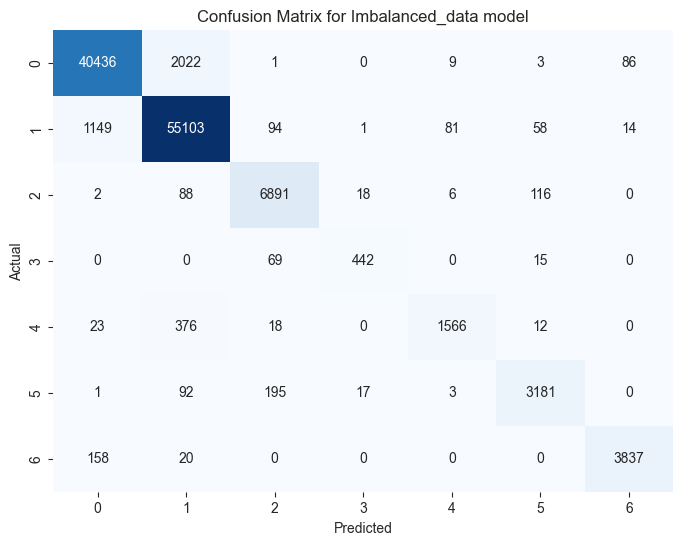

Classification Report for Imbalanced_data model:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96     42557
           1       0.95      0.98      0.97     56500
           2       0.95      0.97      0.96      7121
           3       0.92      0.84      0.88       526
           4       0.94      0.78      0.86      1995
           5       0.94      0.91      0.93      3489
           6       0.97      0.96      0.97      4015

    accuracy                           0.96    116203
   macro avg       0.95      0.91      0.93    116203
weighted avg       0.96      0.96      0.96    116203



In [45]:
# Make predictions
y_pred_probabilities = rf_classifier.predict_proba(X_test)
rf_roc_auc = roc_auc_score(y_test, y_pred_probabilities,multi_class="ovr") #Calculate Roc
print("roc_score",rf_roc_auc)
rf_accuracy =  evaluate_model(rf_classifier,"Imbalanced_data",X_test, y_test)

#### Extra Trees (Random Forests) Classifier

roc_score 0.9982812717044354
Accuracy of Imbalanced model: 95.84%


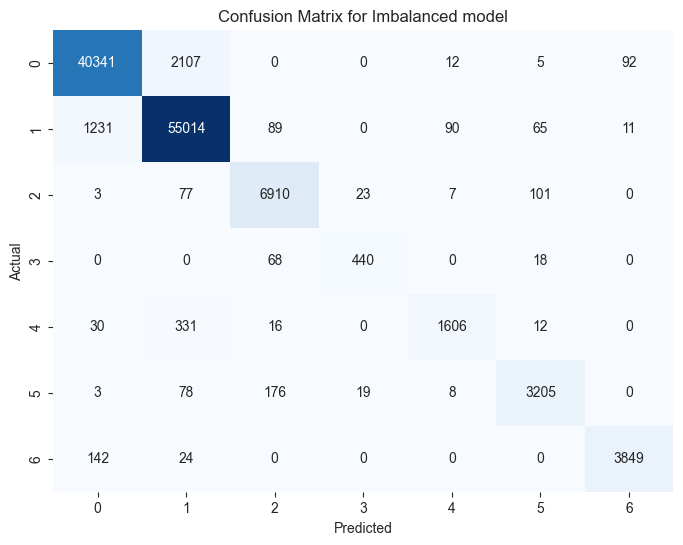

Classification Report for Imbalanced model:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96     42557
           1       0.95      0.97      0.96     56500
           2       0.95      0.97      0.96      7121
           3       0.91      0.84      0.87       526
           4       0.93      0.81      0.86      1995
           5       0.94      0.92      0.93      3489
           6       0.97      0.96      0.97      4015

    accuracy                           0.96    116203
   macro avg       0.95      0.92      0.93    116203
weighted avg       0.96      0.96      0.96    116203



In [46]:
xrf_classifier = ExtraTreesClassifier()
xrf_classifier.fit(X_train, y_train)
# Make predictions
y_pred_probabilities = xrf_classifier.predict_proba(X_test)
xrf_roc_auc = roc_auc_score(y_test, y_pred_probabilities,multi_class="ovr") #Calculate Roc
print("roc_score",xrf_roc_auc)
xrf_accuracy = evaluate_model(xrf_classifier,"Imbalanced",X_test, y_test)

#### Light Gradient Boosting Machine (LightGBM) Classifier

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015384 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2071
[LightGBM] [Info] Number of data points in the train set: 464809, number of used features: 15
[LightGBM] [Info] Start training from score -1.010055
[LightGBM] [Info] Start training from score -0.717554
[LightGBM] [Info] Start training from score -2.787067
[LightGBM] [Info] Start training from score -5.343669
[LightGBM] [Info] Start training from score -4.126990
[LightGBM] [Info] Start training from score -3.511322
[LightGBM] [Info] Start training from score -3.338569
roc_score 0.9785191552635933
Accuracy of Imbalanced model: 85.44%


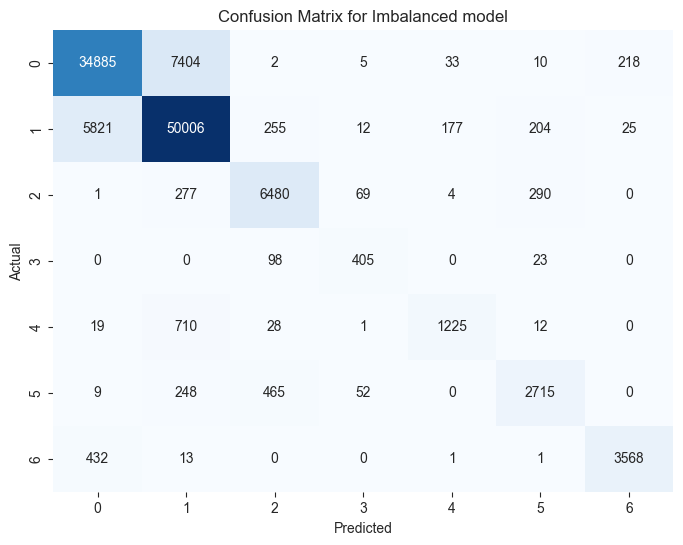

Classification Report for Imbalanced model:
               precision    recall  f1-score   support

           0       0.85      0.82      0.83     42557
           1       0.85      0.89      0.87     56500
           2       0.88      0.91      0.90      7121
           3       0.74      0.77      0.76       526
           4       0.85      0.61      0.71      1995
           5       0.83      0.78      0.81      3489
           6       0.94      0.89      0.91      4015

    accuracy                           0.85    116203
   macro avg       0.85      0.81      0.83    116203
weighted avg       0.85      0.85      0.85    116203



In [47]:
# create model apply fit_evaluate_model
lgbm_classifier = LGBMClassifier()
lgbm_classifier.fit(X_train, y_train)
# Make predictions
y_pred_probabilities = lgbm_classifier.predict_proba(X_test)
lgbm_roc_auc = roc_auc_score(y_test, y_pred_probabilities,multi_class="ovr") #Calculate Roc
print("roc_score",lgbm_roc_auc)
lgbm_accuracy = evaluate_model(lgbm_classifier,"Imbalanced",X_test, y_test)

roc_score 0.9891860386098187
Accuracy of Imbalanced model: 88.65%


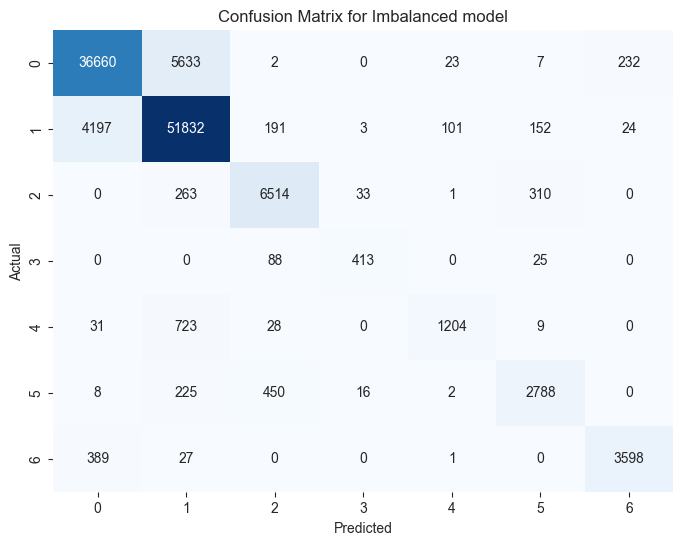

Classification Report for Imbalanced model:
               precision    recall  f1-score   support

           0       0.89      0.86      0.87     42557
           1       0.88      0.92      0.90     56500
           2       0.90      0.91      0.91      7121
           3       0.89      0.79      0.83       526
           4       0.90      0.60      0.72      1995
           5       0.85      0.80      0.82      3489
           6       0.93      0.90      0.91      4015

    accuracy                           0.89    116203
   macro avg       0.89      0.83      0.85    116203
weighted avg       0.89      0.89      0.89    116203



In [50]:
# create model apply fit_evaluate_model 
cat_classifier = CatBoostClassifier(verbose=False)
cat_classifier.fit(X_train, y_train)
# Make predictions
y_pred_probabilities = cat_classifier.predict_proba(X_test)
cat_roc_auc = roc_auc_score(y_test, y_pred_probabilities,multi_class="ovr") #Calculate Roc
print("roc_score",cat_roc_auc)
cat_accuracy = evaluate_model(cat_classifier,"Imbalanced",X_test, y_test)

[14:29:28] WARNING: C:/Users/administrator/workspace/xgboost-win64_release_1.6.0/src/learner.cc:627: 
Parameters: { "verbose" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


roc_score 0.9891860386098187
Accuracy of Imbalanced model: 87.24%


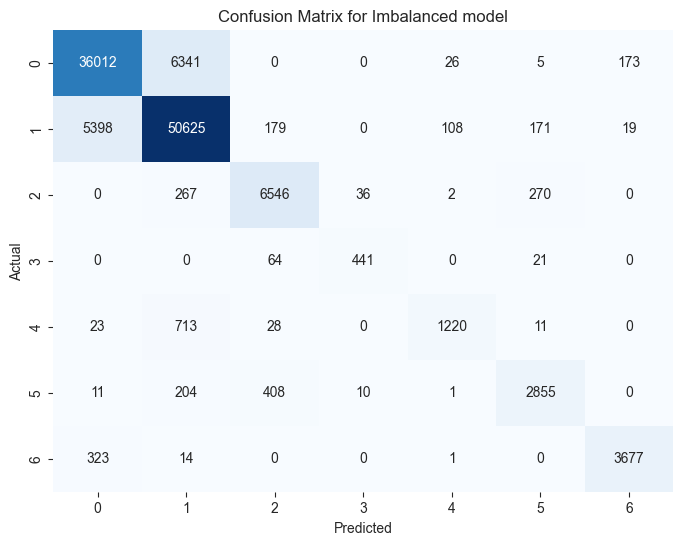

Classification Report for Imbalanced model:
               precision    recall  f1-score   support

           0       0.86      0.85      0.85     42557
           1       0.87      0.90      0.88     56500
           2       0.91      0.92      0.91      7121
           3       0.91      0.84      0.87       526
           4       0.90      0.61      0.73      1995
           5       0.86      0.82      0.84      3489
           6       0.95      0.92      0.93      4015

    accuracy                           0.87    116203
   macro avg       0.89      0.84      0.86    116203
weighted avg       0.87      0.87      0.87    116203



In [51]:
# create model apply fit_evaluate_model 
xgb_classifier = XGBClassifier(verbose=False)
xgb_classifier.fit(X_train, y_train)
# Make predictions
y_pred_probabilities = xgb_classifier.predict_proba(X_test)
xgb_roc_auc = roc_auc_score(y_test, y_pred_probabilities,multi_class="ovr") #Calculate Roc
print("roc_score",cat_roc_auc)
xgb_accuracy = evaluate_model(xgb_classifier,"Imbalanced",X_test, y_test)

## Evaluate all base Models

Text(0.5, 1.0, 'Accuracy Score of Different Models')

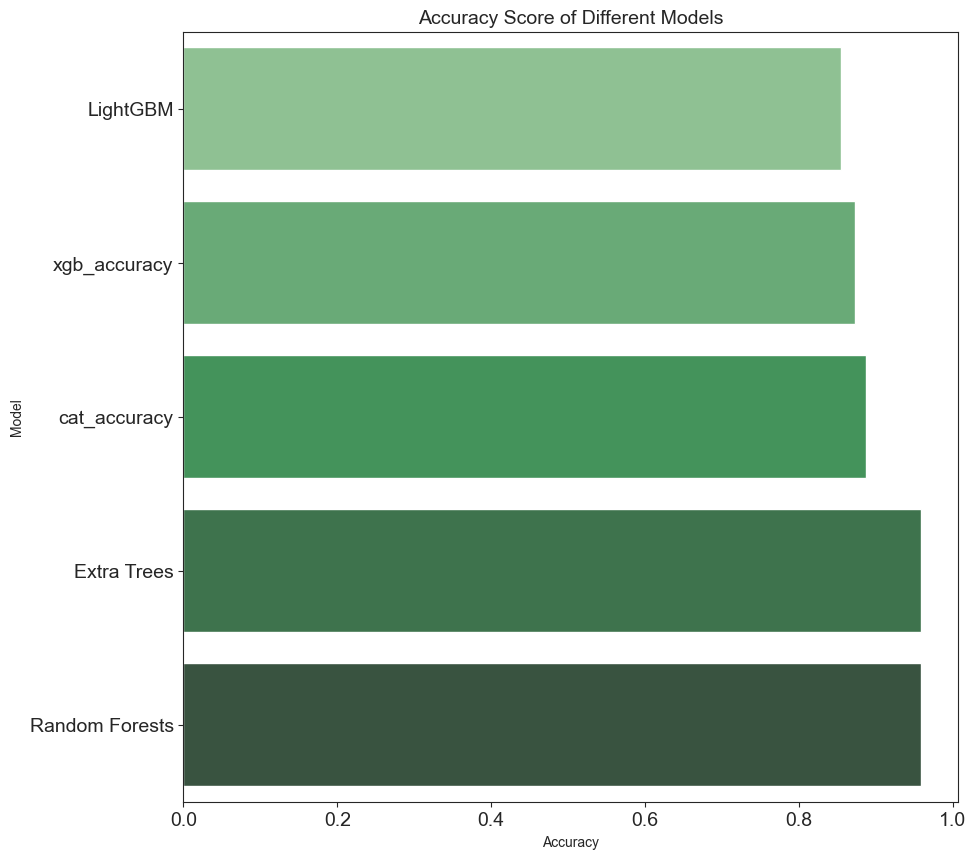

In [52]:
# create dataframe of accuracy and model and sort values
performance_comparison = pd.DataFrame({"Model": [ "LightGBM", "Random Forests", "Extra Trees","cat_accuracy","xgb_accuracy"],
                                       "Accuracy": [ lgbm_accuracy, rf_accuracy, xrf_accuracy,cat_accuracy,xgb_accuracy]})

performance_comparison = performance_comparison.sort_values(by="Accuracy", ascending=True)

# set the plot
plt.figure(figsize=(10,10))
ax = sns.barplot(x="Accuracy", y="Model", data=performance_comparison, palette="Greens_d")

# set title arrange labels
plt.yticks(size = 14)
plt.xticks(size = 14)
plt.title("Accuracy Score of Different Models", size=14)

## Plot Roc Auc Curve

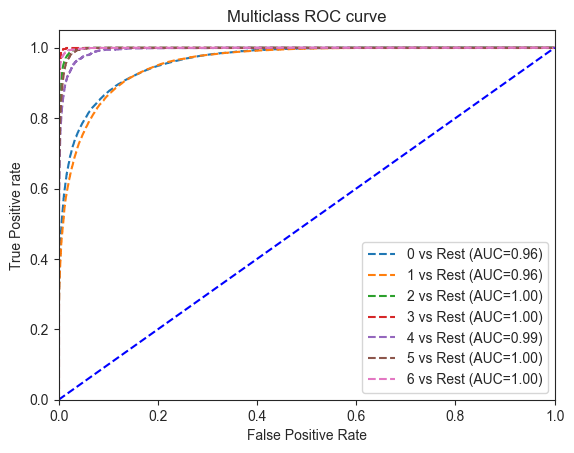

In [53]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve,auc
#binarize the y_values

classes=np.unique(y_test)
y_test_binarized=label_binarize(y_test,classes=np.unique(y_test))

# roc curve for classes
fpr = {}
tpr = {}
thresh ={}
roc_auc = dict()

n_class = 7

for i in range(n_class):    
    fpr[i], tpr[i], thresh[i] = roc_curve(y_test_binarized[:,i], y_pred_probabilities[:,i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    
    # plotting    
    plt.plot(fpr[i], tpr[i], linestyle='--', 
             label='%s vs Rest (AUC=%0.2f)'%(classes[i],roc_auc[i]))

plt.plot([0,1],[0,1],'b--')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.title('Multiclass ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend(loc='lower right')
plt.show()

### Best Model is Random Forest Classifier with 96 % Accuracy, hence we can save this model

In [54]:
import pickle
 
# Save the trained model as a pickle file.
pickle.dump(rf_classifier, open('rf_classifier.pkl', 'wb'))